## MDS BDM with rasters and functional network

## Load Packages

In [1]:
#### STILL REQUIRE CHANGING NUMBER OF STIMULI MANUALLY - HARDCODED INSIDE TDA PIPELINE FUNCTION IN MUTIPLE PLACES

from TDA_Pipeline_with_Victor_Purpura import *
import os 
directory_path = os.path.abspath(os.getcwd())
from SpikeTrainFunctions import *
import sys

In [3]:
# fill in the below two paths yourself:
path = ' ' 
path_NeuronDF = ' '
#'C:/Users/anash/OneDrive - Florida State University/Temperature session/NeuronDF.pickle'
with open(path_NeuronDF,'rb') as file:
    NeuronDF = pickle.load(file)

## select single mouse/date pair for further testing/refinement

In [6]:
filtered_df = NeuronDF[(NeuronDF['MouseID'] == 'CB280') & (NeuronDF['Date'] == '121521')]
filtered_df

,Recording Type,MouseID,Date,NeuronID,Taste,Neuron,Trial,-2000,-1999,-1998,...,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999
19577,Neuron,CB280,121521,SU_26,0,255,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19578,Neuron,CB280,121521,SU_28,0,256,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19579,Neuron,CB280,121521,SU_44,0,257,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19580,Neuron,CB280,121521,SU_46,0,258,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19581,Neuron,CB280,121521,SU_64,0,259,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20076,Neuron,CB280,121521,SU_28,2,256,24,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20077,Neuron,CB280,121521,SU_44,2,257,24,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
20078,Neuron,CB280,121521,SU_46,2,258,24,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20079,Neuron,CB280,121521,SU_64,2,259,24,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
q_values = [2.005/(1.0 * pq.ms)]
Mouse = 'CB280'
Date = '121521'
number_of_trials = 10
number_of_iterations = 1
random_state = 1


## Run the pipeline for a single q value and keep all values from each iteration and all of our barcodes:
mean_lou_score, scores_each_itr, barcodes, all_ytrue, all_ypred, bdm, rasters, distance_matrices = TDA_Pipeline(NeuronDF, Mouse = Mouse, Date = Date, number_of_trials=number_of_trials,
                             random_state=random_state, q=q_values[0], number_of_iterations=number_of_iterations)

In [26]:
mean_lou_score

0.7666666666666667

In [28]:
scores_each_itr

[0.7666666666666667]

In [36]:
def DM_Plot_notext(DM,fontsize = 10,figsize = (8,8), axes = None,colorbar = None): # DM = Distance Matrix Plotter 
    """
    INPUT: Computed Distance Matrix as a NxN numpy array
    Output: Plots the distance matrix with colorbar and annotated values for each entry
    """
    
    if axes is None:
        fig, axes = plt.subplots(figsize = figsize)
    
    im = axes.imshow(DM)
    if colorbar:
        axes.figure.colorbar(im, ax = axes)
    
    #for i in range(DM.shape[0]):
        #for j in range(DM.shape[1]):
            #axes.text(j,i,f'{DM[i,j]:.2f}', va = 'center', ha = 'center', fontsize = fontsize, color = 'white')
            
    axes.set_xticks([i for i in range(DM.shape[0])])
    axes.set_yticks([i for i in range(DM.shape[1])])

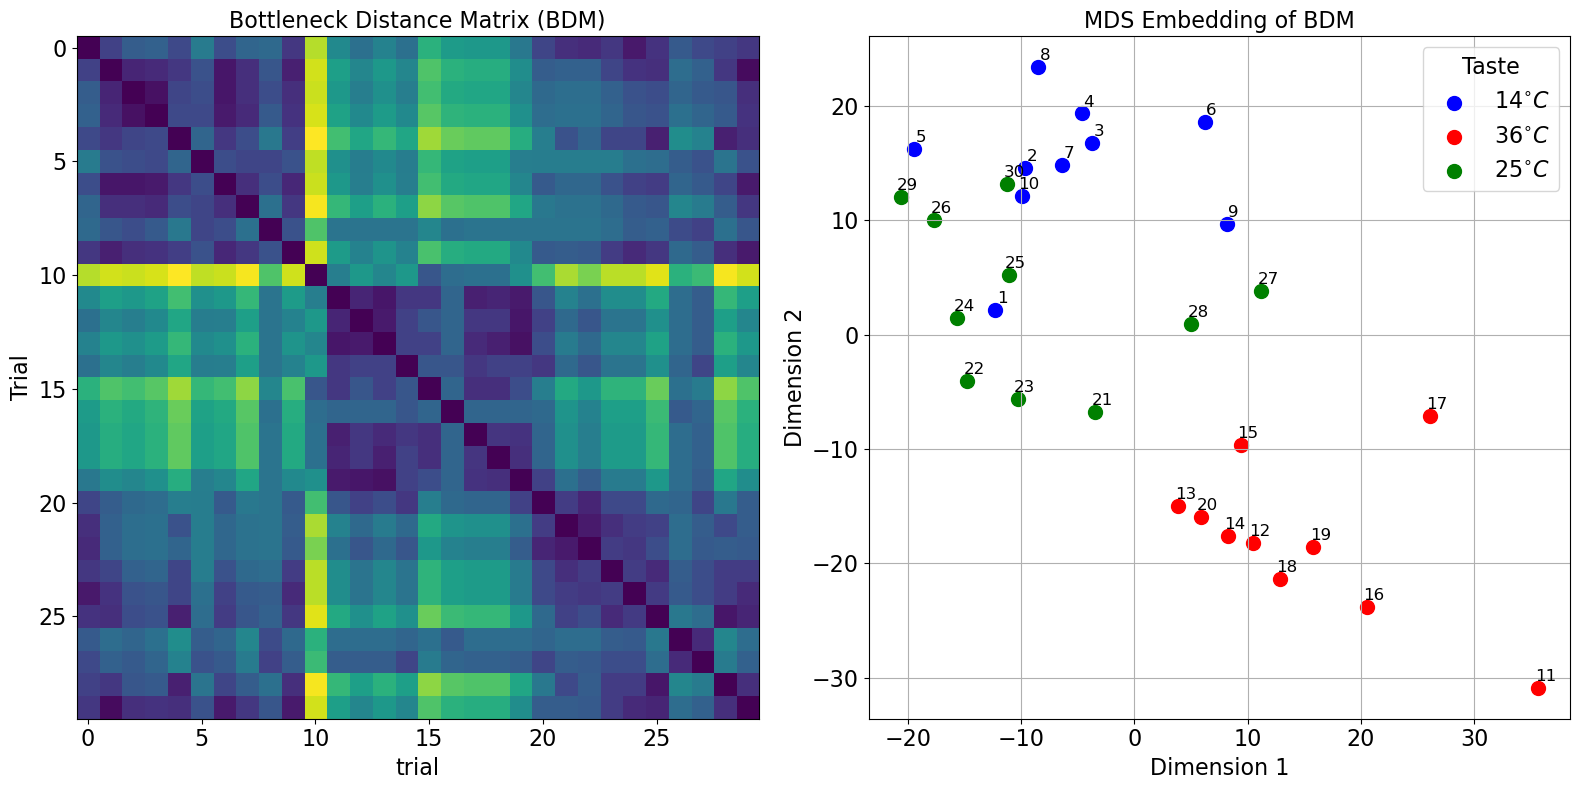

In [136]:
from sklearn.manifold import MDS
import matplotlib.pyplot as plt
import numpy as np

mds = MDS(n_components=2, dissimilarity='precomputed', random_state=41, normalized_stress='auto')
coords = mds.fit_transform(bdm)
labels = np.array(number_of_trials * [0] + number_of_trials * [1] + number_of_trials * [2])
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(16, 8))
axs = axs.flatten()

ax = axs[0]
DM_Plot_notext(bdm, axes=ax)
ax.set_title('Bottleneck Distance Matrix (BDM)', fontsize=16)

n = bdm.shape[0]
tick_locs = np.arange(0, n, 5)
ax.set_xticks(tick_locs)
ax.set_yticks(tick_locs)
ax.set_xticklabels(tick_locs, fontsize=16)
ax.set_yticklabels(tick_locs, fontsize=16)

ax.set_xlabel("trial", fontsize=16)
ax.set_ylabel("Trial", fontsize=16)
ax = axs[1]
ax.grid(True)
label_mapping = {0: r"$14^{\circ} C$", 1: r"$36^{\circ} C$", 2: r"$25^{\circ} C$"}  # legend mapping
color = ['blue','red','green']

for label in np.unique(labels):
    ax.scatter(coords[labels == label, 0],
               coords[labels == label, 1],
               label=f'{label_mapping[label]}',s=100,c=color[label])

# Annotate each point with its trial index
for i in range(len(coords)):
    ax.annotate(str(i + 1), (coords[i, 0], coords[i, 1]),
                textcoords="offset points", xytext=(5, 5), ha='center', fontsize=12)


ax.set_title('MDS Embedding of BDM', fontsize=16)
ax.tick_params(axis='both', labelsize=16)
ax.set_xlabel('Dimension 1', fontsize=16)
ax.set_ylabel('Dimension 2', fontsize=16)
ax.legend(title='Taste', fontsize=16, title_fontsize=16)


plt.tight_layout()
fig.savefig('bdm_mds_cb280_121521.svg', dpi=300, bbox_inches='tight',  format='svg')
fig.savefig('bdm_mds_cb280_121521.pdf', dpi=300, bbox_inches='tight',  format='pdf')
plt.show()


In [40]:
barcodes[-1][4]

array([[  0.,   5.],
       [  0.,  10.],
       [  0.,  25.],
       [  0.,  35.],
       [  0., 135.],
       [  0.,  inf]])

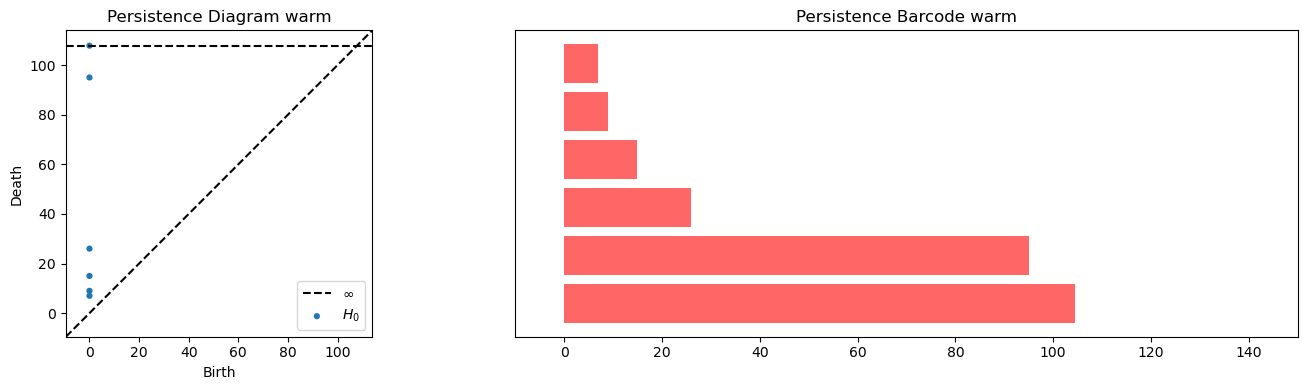

In [207]:
fig, axs = plt.subplots(nrows = 1,ncols = 2, figsize = (15,4))
axs = axs.flatten()
ax = axs[0]
plot_diagrams(barcodes[-1][14],ax = ax)
ax.set_title('Persistence Diagram warm')
ax = axs[1]
gd.plot_persistence_barcode(barcodes[-1][14], axes=ax, colormap="red") 
ax.set_xlim(-10,150)
ax.set_title('Persistence Barcode warm')

plt.tight_layout()
fig.savefig('barcode_warm_14_cb280_121521.svg', dpi=300, bbox_inches='tight',  format='svg')
#fig.savefig('bdm_mds_cb280_121521.pdf', dpi=300, bbox_inches='tight',  format='pdf')
plt.show()

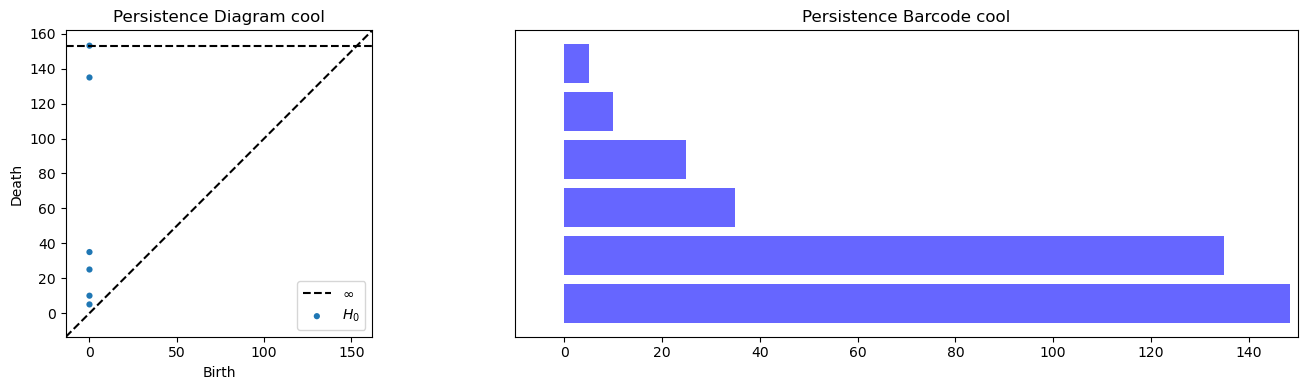

In [209]:
fig, axs = plt.subplots(nrows = 1,ncols = 2, figsize = (15,4))
axs = axs.flatten()

ax = axs[0]
plot_diagrams(barcodes[-1][4],ax = ax)
ax.set_title('Persistence Diagram cool')

ax = axs[1]
gd.plot_persistence_barcode(barcodes[-1][4], axes=ax, colormap="blue")  # Apply color mapping
ax.set_xlim(-10,150)
ax.set_title('Persistence Barcode cool')

plt.tight_layout()
fig.savefig('barcode_cool_4_cb280_121521.svg', dpi=300, bbox_inches='tight',  format='svg')
plt.show()

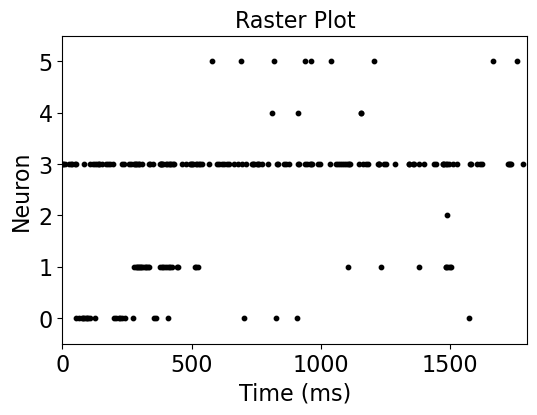

In [193]:
plot_raster_binary(rasters[4], point_size=10, y_spacing=1.0)
plt.savefig('raster_4_cb280_121521.svg', dpi=300, bbox_inches='tight',  format='svg')
plt.savefig('raster_4_cb280_121521.pdf', dpi=300, bbox_inches='tight',  format='pdf')
plt.show()

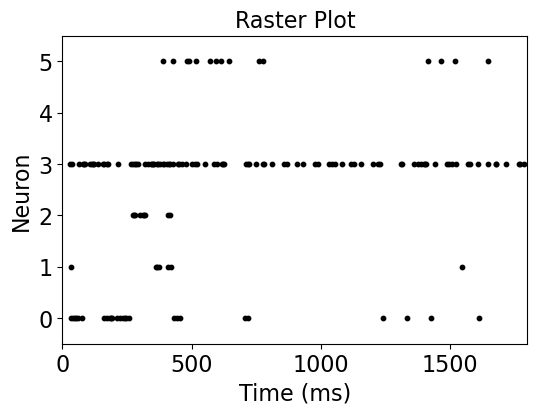

In [195]:
plot_raster_binary(rasters[14], point_size=10, y_spacing=1.0)
plt.savefig('raster_14_cb280_121521.svg', dpi=300, bbox_inches='tight',  format='svg')
plt.show()

In [176]:
def plot_raster_binary(SA,x_lim=None,point_size=400,lick_times=None,ax=None,
                       y_spacing=1.0,spike_color='k',lick_color='blue',fontsize=16,
                       title="Raster Plot"):
    """
    SA : binary raster array of shape (n_neurons, n_timepoints)
         SA[i,t] = 1 if neuron i fired at time t else 0
    """

    import numpy as np
    import matplotlib.pyplot as plt

    n_neurons, n_timepoints = SA.shape

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    # Default x-limits from timepoints
    if x_lim is None:
        x_lim = (0, n_timepoints)

    # Loop through each neuron
    for neuron_idx in range(n_neurons):
        spike_times = np.where(SA[neuron_idx] == 1)[0]  # time points
        if len(spike_times) > 0:
            y_values = np.full_like(spike_times, neuron_idx * y_spacing)
            ax.scatter(spike_times,
                       y_values,
                       s=point_size,
                       c=spike_color)

    # Optional lick markers
    if lick_times is not None:
        lick_times = np.array(lick_times)
        ax.scatter(lick_times,
                   np.full_like(lick_times, -1 * y_spacing),
                   marker='^',
                   s=point_size * 100,
                   c=lick_color,
                   label='Licks')
        ax.legend(fontsize=fontsize)

    # Formatting
    ax.set_xlim(x_lim)
    ax.set_ylim([-0.5, n_neurons-0.5])
    ax.set_xlabel("Time (ms)", fontsize=fontsize)
    ax.set_ylabel("Neuron", fontsize=fontsize)
    ax.set_title(title, fontsize=fontsize)
    ax.tick_params(axis='both', labelsize=fontsize)

    return ax


In [58]:
def connected_components_at_scale(dm, eps):
    """
    dm : distance matrix (n_neurons x n_neurons)
    eps : scale threshold (float)
    Returns list of connected components (each a list of neuron indices)
    """
    n = dm.shape[0]

    parent = list(range(n))  # union–find parent array

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        pa, pb = find(a), find(b)
        if pa != pb:
            parent[pb] = pa

    # connect nodes whose distance ≤ eps
    for i in range(n):
        for j in range(i+1, n):
            if dm[i,j] <= eps:
                union(i, j)

    # extract groups
    components = {}
    for i in range(n):
        p = find(i)
        if p not in components:
            components[p] = []
        components[p].append(i)

    return list(components.values())


In [128]:
trial_index = 4
dm = distance_matrices[trial_index]
components = connected_components_at_scale(dm, eps=20)

print("Connected components at scale 20:")
for comp in components:
    print(comp)


Connected components at scale 20:
[0]
[1]
[2, 4, 5]
[3]


In [130]:
trial_index = 14
dm = distance_matrices[trial_index]
components = connected_components_at_scale(dm, eps=20)

print("Connected components at scale 20:")
for comp in components:
    print(comp)


Connected components at scale 20:
[0]
[1, 2, 4, 5]
[3]


In [72]:
# open file with single neuron scores to know what direction to add neurons in
merged_df = pd.read_csv(f'{path}/gctemp_sna_withMDpair_info.csv')
merged_df

,Neuron,SNAscore,MouseID,Date
0,0.0,0.577778,CB279,121621
1,1.0,0.351852,CB279,121621
2,2.0,0.314815,CB279,121621
3,3.0,0.711111,CB279,121621
4,4.0,0.607407,CB279,121621
...,...,...,...,...
428,428.0,0.348148,CB317,111022
429,429.0,0.381481,CB317,111022
430,430.0,0.344444,CB317,111022
431,431.0,0.337037,CB317,111022


In [126]:
merged_df_reduce = merged_df[(merged_df['MouseID'] == 'CB317')]
merged_df_reduce = merged_df_reduce[(merged_df_reduce['Date'] == 110822)]
merged_df_reduce

,Neuron,SNAscore,MouseID,Date
396,396.0,0.592593,CB317,110822
397,397.0,0.481481,CB317,110822
398,398.0,0.392593,CB317,110822
399,399.0,0.537037,CB317,110822
400,400.0,0.359259,CB317,110822
401,401.0,0.433333,CB317,110822
402,402.0,0.529630,CB317,110822
403,403.0,0.425926,CB317,110822
404,404.0,0.555556,CB317,110822
405,405.0,0.277778,CB317,110822


In [128]:
merged_df_reduce.sort_values(by='SNAscore')

,Neuron,SNAscore,MouseID,Date
405,405.0,0.277778,CB317,110822
400,400.0,0.359259,CB317,110822
412,412.0,0.366667,CB317,110822
406,406.0,0.388889,CB317,110822
398,398.0,0.392593,CB317,110822
409,409.0,0.411111,CB317,110822
403,403.0,0.425926,CB317,110822
407,407.0,0.429630,CB317,110822
401,401.0,0.433333,CB317,110822
413,413.0,0.462963,CB317,110822
